# Comparing Data Visualizations

This notebook is for the Pluralsight "Data Visualizations in Python" course assignment.
We're going to load up the countries dataset, take a look at life expectancy for Asia
and Africa back in 1952, and then compare the two using histograms side by side.

In [1]:
# First, let's bring in the libraries we need.
# pandas is going to help us load and filter the CSV data.
# matplotlib.pyplot is what we'll use to actually draw our charts.
import pandas as pd
import matplotlib.pyplot as plt

# This just makes sure our charts show up nicely inside the notebook itself.
%matplotlib inline

In [2]:
# Now let's load the countries.csv file into a pandas DataFrame.
# A DataFrame is basically just a table, like a spreadsheet, that we can
# filter and slice however we need.
df = pd.read_csv('countries.csv')

# Let's peek at the first few rows just to make sure everything loaded correctly
# and to remind ourselves what columns we have to work with.
df.head()

,country,continent,year,lifeExpectancy,population,gdpPerCapita
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [3]:
# The assignment asks us to compare life expectancy for Asia and Africa
# specifically for the year 1952, so let's filter the data down to that.

# This grabs every row where the continent is Asia AND the year is 1952.
asia_1952 = df[(df['continent'] == 'Asia') & (df['year'] == 1952)]

# Same idea here, but for Africa instead.
africa_1952 = df[(df['continent'] == 'Africa') & (df['year'] == 1952)]

# Quick sanity check - let's see how many countries we ended up with for each.
print('Number of Asian countries in 1952:', len(asia_1952))
print('Number of African countries in 1952:', len(africa_1952))

Number of Asian countries in 1952: 33
Number of African countries in 1952: 52


## Comparing life expectancy across countries (1952)

The assignment calls this a "time series," but since we're only looking at a single
year (1952), what we're really comparing is life expectancy country by country for
Asia vs Africa. A line chart works well here to see how the values trend across
each continent's list of countries.

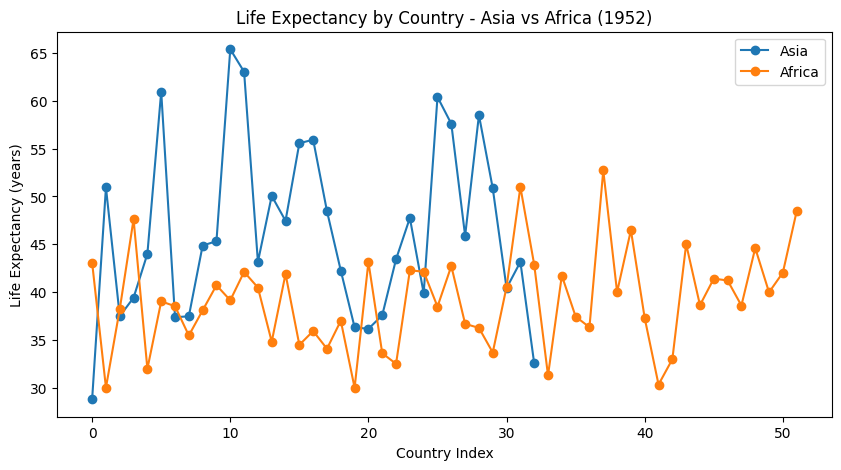

In [4]:
# Here we're plotting life expectancy for each country in our filtered data,
# one line for Asia and one line for Africa, so we can visually compare them.

plt.figure(figsize=(10, 5))

# .values just pulls the raw numbers out of the column so matplotlib can plot them
plt.plot(asia_1952['lifeExpectancy'].values, label='Asia', marker='o')
plt.plot(africa_1952['lifeExpectancy'].values, label='Africa', marker='o')

# Adding labels and a title so anyone looking at this chart knows what it's showing
plt.title('Life Expectancy by Country - Asia vs Africa (1952)')
plt.xlabel('Country Index')
plt.ylabel('Life Expectancy (years)')
plt.legend()
plt.show()

## Histograms: Asia vs Africa life expectancy

Now let's use `hist()` to see the *distribution* of life expectancy values for
each continent - basically, how many countries fall into each life expectancy
range. We'll use `subplot()` to put both histograms side by side so they're
easy to compare at a glance.

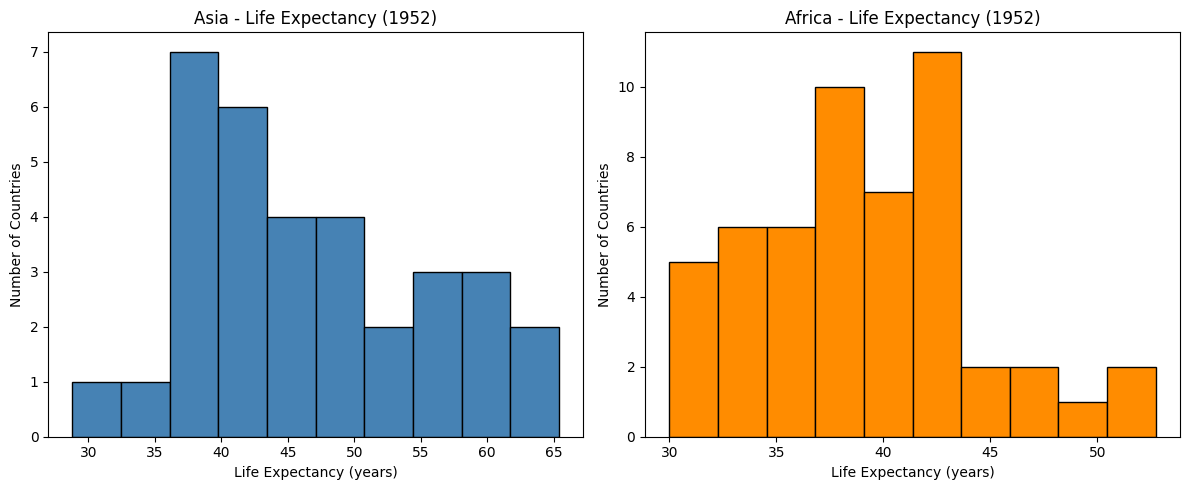

In [5]:
# subplot(rows, columns, position) sets up a grid of charts.
# Here we're making 1 row, 2 columns, so our two histograms sit side by side.

plt.figure(figsize=(12, 5))

# First histogram - Asia, goes in position 1 (the left side)
plt.subplot(1, 2, 1)
plt.hist(asia_1952['lifeExpectancy'], bins=10, color='steelblue', edgecolor='black')
plt.title('Asia - Life Expectancy (1952)')
plt.xlabel('Life Expectancy (years)')
plt.ylabel('Number of Countries')

# Second histogram - Africa, goes in position 2 (the right side)
plt.subplot(1, 2, 2)
plt.hist(africa_1952['lifeExpectancy'], bins=10, color='darkorange', edgecolor='black')
plt.title('Africa - Life Expectancy (1952)')
plt.xlabel('Life Expectancy (years)')
plt.ylabel('Number of Countries')

# tight_layout just cleans up spacing so the titles/labels don't overlap
plt.tight_layout()
plt.show()

## Wrap-up

Looking at these two charts, Africa's life expectancy in 1952 is generally lower
and more tightly clustered together, while Asia has a wider spread, with a few
countries reaching noticeably higher life expectancy than most African countries
at the time. This kind of side-by-side histogram comparison makes it a lot easier
to spot those differences than just reading the raw numbers from a table.